<a href="https://colab.research.google.com/github/Lopez-Max/MachineLearning/blob/main/Lopez_HW_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Part 1: Segmentation dataset from OSF
!wget -O dataset.zip "https://osf.io/2rjx7/download"
!unzip -q dataset.zip

# Part 2: Object Detection dataset from Roboflow (21,582 labels)
!wget -O uno_cards.zip "https://public.roboflow.com/ds/f9yuuuDkip?key=e9ELWmqYvL"
!unzip -q uno_cards.zip

--2025-10-27 15:36:28--  https://osf.io/2rjx7/download
Resolving osf.io (osf.io)... 35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://osf.io/download/2rjx7 [following]
--2025-10-27 15:36:30--  https://osf.io/download/2rjx7
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 308 PERMANENT REDIRECT
Location: https://osf.io/download/2rjx7/ [following]
--2025-10-27 15:36:30--  https://osf.io/download/2rjx7/
Reusing existing connection to osf.io:443.
HTTP request sent, awaiting response... 302 FOUND
Location: https://files.osf.io/v1/resources/zq9pc/providers/osfstorage/680690fc56567576c063ee5c [following]
--2025-10-27 15:36:30--  https://files.osf.io/v1/resources/zq9pc/providers/osfstorage/680690fc56567576c063ee5c
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP reques

Using device: cuda


Epoch 1/5: 100%|██████████| 41/41 [00:04<00:00,  8.88it/s]


Epoch 1 Loss: 0.4179


Epoch 2/5: 100%|██████████| 41/41 [00:03<00:00, 13.45it/s]


Epoch 2 Loss: 0.2547


...

Epoch 3 Loss: 0.1856


Epoch 4/5: 100%|██████████| 41/41 [00:03<00:00, 13.50it/s]


Epoch 4 Loss: 0.1317


Epoch 5/5: 100%|██████████| 41/41 [00:03<00:00, 13.39it/s]


Epoch 5 Loss: 0.1133

Test Pixel Accuracy: 0.9342


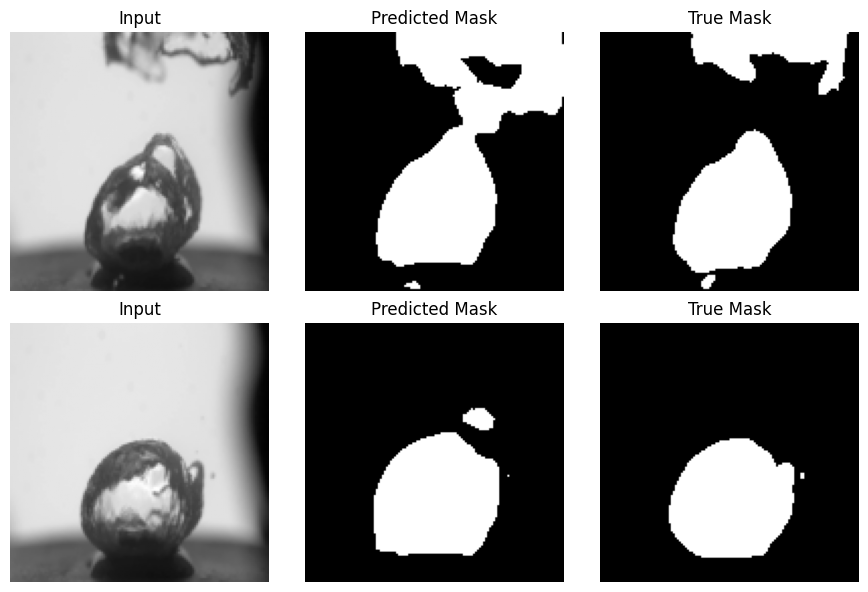

In [ ]:
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.transforms.functional as TF

# -----------------------------
# Dataset
# -----------------------------
class BoilingSegDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None, img_size=(128, 128)):
        self.images = sorted(glob(os.path.join(images_dir, "*")))
        self.masks = sorted(glob(os.path.join(masks_dir, "*")))
        assert len(self.images) == len(self.masks), "Mismatch between images and masks!"
        self.transform = transform
        self.img_size = img_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("L")  # grayscale
        mask = Image.open(self.masks[idx]).convert("L")

        if self.transform:
            # Apply same transform to both image and mask
            img = self.transform(img)
            # For mask, only resize and convert to tensor (no normalization)
            mask = TF.resize(mask, self.img_size)
            mask = TF.to_tensor(mask)
        else:
            img = T.ToTensor()(img)
            mask = T.ToTensor()(mask)

        # Binarize mask
        mask = (mask > 0.5).float()  # [1, H, W]
        return img, mask

# -----------------------------
# UNet Model
# -----------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64,128,256,512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        # Down
        for feat in features:
            self.downs.append(DoubleConv(in_channels, feat))
            in_channels = feat

        # Up
        for feat in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feat*2, feat, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feat*2, feat))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skips[idx//2]
            if x.shape != skip.shape:
                x = TF.resize(x, size=skip.shape[2:])
            x = torch.cat((skip, x), dim=1)
            x = self.ups[idx+1](x)

        return self.final(x)

# -----------------------------
# Helper functions
# -----------------------------
def pixel_accuracy(preds, targets, threshold=0.5):
    preds = (preds > threshold).float()
    correct = (preds == targets).float().sum()
    total = torch.numel(preds)
    return (correct / total).item()

def show_examples(model, dataset, device, num=2):
    model.eval()
    fig, axs = plt.subplots(num, 3, figsize=(9, 3*num))
    with torch.no_grad():
        for i in range(num):
            img, mask = dataset[i]
            x = img.unsqueeze(0).to(device)
            pred = torch.sigmoid(model(x)).cpu().squeeze().numpy()

            # Denormalize image for display
            img_np = img.squeeze().numpy()
            img_np = img_np * 0.5 + 0.5  # Reverse normalization
            img_np = np.clip(img_np, 0, 1)

            mask_np = mask.squeeze().numpy()
            pred_bin = (pred > 0.5).astype(np.float32)

            axs[i,0].imshow(img_np, cmap='gray')
            axs[i,0].set_title("Input")
            axs[i,1].imshow(pred_bin, cmap='gray')
            axs[i,1].set_title("Predicted Mask")
            axs[i,2].imshow(mask_np, cmap='gray')
            axs[i,2].set_title("True Mask")
            for j in range(3):
                axs[i,j].axis('off')
    plt.tight_layout()
    plt.show()

# -----------------------------
# Training Loop
# -----------------------------
def train_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # Folders
    images_dir = "Data/Images"
    masks_dir  = "Data/Masks"

    img_size = (128, 128)  # Define image size
    transform = T.Compose([
        T.Resize(img_size),
        T.ToTensor(),
        T.Normalize([0.5],[0.5])
    ])

    dataset = BoilingSegDataset(images_dir, masks_dir, transform=transform, img_size=img_size)
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_ds, test_ds = random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False)

    model = UNet(in_channels=1, out_channels=1, features=[32,64,128,256]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epochs = 5  # Reduced for faster training
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1} Loss: {epoch_loss:.4f}")

    # Evaluate on test data
    model.eval()
    total_acc = 0
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = torch.sigmoid(model(imgs))
            total_acc += pixel_accuracy(preds, masks)
    avg_acc = total_acc / len(test_loader)
    print(f"\nTest Pixel Accuracy: {avg_acc:.4f}")

    # Show results
    show_examples(model, test_ds, device)

if __name__ == "__main__":
    train_model()

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 76.4 MB/s eta 0:00:00


YOLOv8 OBJECT DETECTION - ROBOFLOW DATASET (21,582 LABELS)

Step 1: Downloading and setting up dataset...
Extracting dataset...
Auto-download failed: Command '['unzip', '-q', 'dataset.zip']' returned non-zero exit status 1.
Attempting to find manually downloaded dataset...
Dataset loaded from: .
Dataset configuration: ./data.yaml

Dataset Structure:
  train : 18885 images, 18885 labels
  valid :  1798 images,  1798 labels
  test  :   899 images,   899 labels

Step 2: Training YOLOv8 model with transfer learning...
This may take a while depending on your hardware...

Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=F

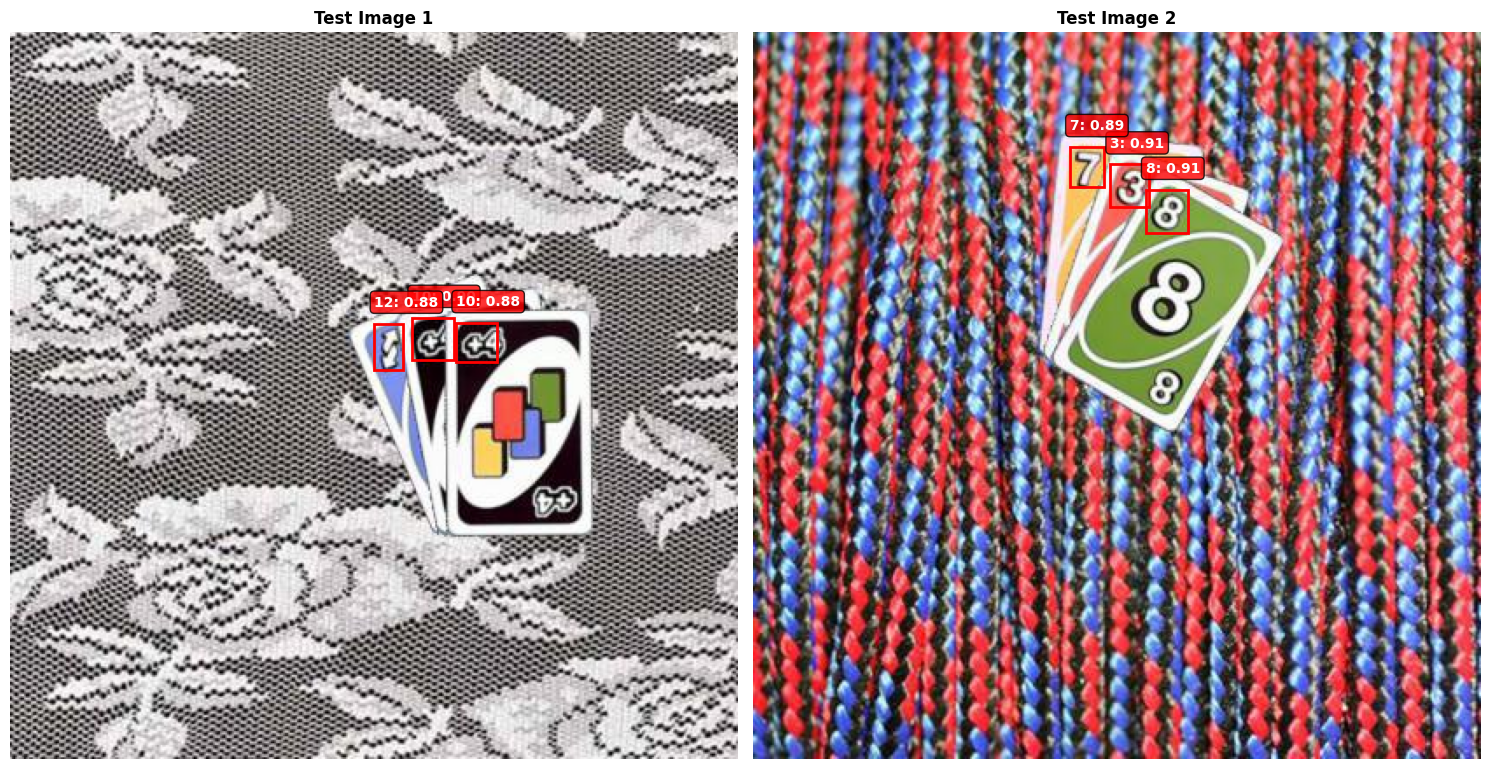


Visualization saved as 'predictions_visualization.png'

Step 5: Detailed prediction analysis...

DETAILED PREDICTION ANALYSIS

Image 1: 356317098_jpg.rf.4fdced78d1ec792a398af3d70809232e.jpg
----------------------------------------------------------------------
Total objects detected: 3

Object 1:
  Class: 10
  Confidence: 0.9007
  Bounding Box: [229.4, 163.2, 253.5, 187.5]
  Box Size: 24.1 x 24.3 pixels

Object 2:
  Class: 10
  Confidence: 0.8839
  Bounding Box: [254.6, 166.2, 277.8, 188.5]
  Box Size: 23.2 x 22.3 pixels

Object 3:
  Class: 12
  Confidence: 0.8783
  Bounding Box: [207.8, 166.6, 224.5, 193.2]
  Box Size: 16.7 x 26.6 pixels


Image 2: 145835836_jpg.rf.a5a7c5749412ee6169f19acd92276ffe.jpg
----------------------------------------------------------------------
Total objects detected: 3

Object 1:
  Class: 3
  Confidence: 0.9108
  Bounding Box: [203.9, 75.5, 226.5, 99.7]
  Box Size: 22.5 x 24.2 pixels

Object 2:
  Class: 8
  Confidence: 0.9096
  Bounding Box: [224.3, 90.0, 

In [ ]:
"""
YOLOv8 Object Detection - Roboflow Dataset (21,582 labels)
Transfer Learning for Object Detection using Pretrained YOLOv8
"""

# Install required packages
# !pip install ultralytics opencv-python matplotlib

import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
import yaml

# ===================================
# PART 1: DATASET DOWNLOAD & SETUP
# ===================================

def download_dataset():
    """
    Download the larger Roboflow dataset with 21,582 labeled examples.
    """
    import subprocess

    print("Downloading dataset with 21,582 labels from Roboflow...")

    # Download dataset
    subprocess.run([
        'wget', '-O', 'dataset.zip',
        'https://public.roboflow.com/ds/f9yuuuDkip?key=e9ELWmqYvL'
    ], check=True)

    print("Extracting dataset...")
    # Extract dataset
    subprocess.run(['unzip', '-q', 'dataset.zip'], check=True)

    print("Dataset downloaded and extracted successfully!\n")

    # Find the extracted dataset directory
    # Roboflow typically extracts to current directory with structure
    return find_dataset_directory()

def find_dataset_directory():
    """
    Find the extracted dataset directory containing data.yaml
    Dataset structure should be:
    - test/images/ and test/labels/
    - train/images/ and train/labels/
    - valid/images/ and valid/labels/
    - data.yaml
    """
    # Check current directory first
    if (os.path.exists('train') and os.path.exists('valid') and
        os.path.exists('test') and os.path.exists('data.yaml')):
        return '.'

    # Check common locations
    possible_paths = [
        './detection_data',
        './dataset',
        './uno_cards',
    ]

    for path in possible_paths:
        if (os.path.exists(os.path.join(path, 'train')) and
            os.path.exists(os.path.join(path, 'valid')) and
            os.path.exists(os.path.join(path, 'data.yaml'))):
            return path

    # Search in current directory for the structure
    for root, dirs, files in os.walk('.', maxdepth=2):
        if ('train' in dirs and 'valid' in dirs and
            'test' in dirs and 'data.yaml' in files):
            return root

    raise FileNotFoundError("Could not find dataset directory with train/valid/test folders and data.yaml")

def setup_manual_dataset(dataset_path):
    """
    If you've manually downloaded the dataset, ensure it has this structure:
    dataset_path/
        ├── train/
        │   ├── images/
        │   └── labels/
        ├── valid/
        │   ├── images/
        │   └── labels/
        ├── test/
        │   ├── images/
        │   └── labels/
        └── data.yaml
    """
    data_yaml_path = os.path.join(dataset_path, 'data.yaml')
    if not os.path.exists(data_yaml_path):
        raise FileNotFoundError(f"data.yaml not found at {data_yaml_path}")

    return dataset_path

# ===================================
# PART 2: TRANSFER LEARNING WITH YOLOv8
# ===================================

def train_yolov8_model(dataset_path, epochs=50, img_size=640, batch_size=16):
    """
    Train YOLOv8 model using transfer learning.

    Args:
        dataset_path: Path to dataset with data.yaml
        epochs: Number of training epochs
        img_size: Input image size
        batch_size: Training batch size
    """
    # Load pretrained YOLOv8 model
    # Options: yolov8n.pt (nano), yolov8s.pt (small), yolov8m.pt (medium),
    #          yolov8l.pt (large), yolov8x.pt (extra large)
    model = YOLO('yolov8n.pt')  # Using nano model for faster training

    # Train the model
    results = model.train(
        data=os.path.join(dataset_path, 'data.yaml'),
        epochs=epochs,
        imgsz=img_size,
        batch=batch_size,
        name='uno_cards_detection',
        patience=10,  # Early stopping patience
        save=True,
        plots=True,
        device='cuda' if os.path.exists('/dev/nvidia0') else 'cpu'
    )

    return model, results

# ===================================
# PART 3: MODEL EVALUATION
# ===================================

def evaluate_model(model, dataset_path):
    """
    Evaluate the trained model on test/validation set.
    Returns mAP50 and mAP50-95 metrics.
    """
    # Validate the model
    metrics = model.val(
        data=os.path.join(dataset_path, 'data.yaml'),
        split='test'  # or 'val' depending on your dataset
    )

    # Extract performance metrics
    map50 = metrics.box.map50  # mAP at IoU threshold 0.5
    map50_95 = metrics.box.map  # mAP at IoU thresholds 0.5:0.95

    print("\n" + "="*50)
    print("PERFORMANCE METRICS")
    print("="*50)
    print(f"mAP50:     {map50:.4f}")
    print(f"mAP50-95:  {map50_95:.4f}")
    print("="*50 + "\n")

    return map50, map50_95, metrics

# ===================================
# PART 4: VISUALIZATION
# ===================================

def visualize_predictions(model, test_images_path, num_images=2, conf_threshold=0.25):
    """
    Visualize predictions on test images with bounding boxes and labels.

    Args:
        model: Trained YOLO model
        test_images_path: Path to test images directory
        num_images: Number of images to visualize
        conf_threshold: Confidence threshold for predictions
    """
    # Get test images
    image_files = list(Path(test_images_path).glob('*.jpg')) + \
                  list(Path(test_images_path).glob('*.png'))

    if len(image_files) < num_images:
        num_images = len(image_files)

    # Create figure
    fig, axes = plt.subplots(1, num_images, figsize=(15, 8))
    if num_images == 1:
        axes = [axes]

    for idx, img_path in enumerate(image_files[:num_images]):
        # Run inference
        results = model.predict(
            source=str(img_path),
            conf=conf_threshold,
            save=False,
            verbose=False
        )

        # Load image
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display image
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(f'Test Image {idx+1}', fontsize=12, fontweight='bold')

        # Draw predictions
        result = results[0]
        boxes = result.boxes

        for box in boxes:
            # Get box coordinates
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().numpy()
            cls = int(box.cls[0].cpu().numpy())
            class_name = result.names[cls]

            # Draw bounding box
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            axes[idx].add_patch(rect)

            # Add label with confidence
            label = f'{class_name}: {conf:.2f}'
            axes[idx].text(
                x1, y1-10,
                label,
                color='white',
                fontsize=10,
                fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='red', alpha=0.8)
            )

    plt.tight_layout()
    plt.savefig('predictions_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nVisualization saved as 'predictions_visualization.png'")

# ===================================
# PART 5: DETAILED PREDICTION ANALYSIS
# ===================================

def detailed_prediction_analysis(model, test_images_path, num_images=2):
    """
    Perform detailed analysis of predictions including all bounding boxes,
    class predictions, and confidence values.
    """
    image_files = list(Path(test_images_path).glob('*.jpg')) + \
                  list(Path(test_images_path).glob('*.png'))

    print("\n" + "="*70)
    print("DETAILED PREDICTION ANALYSIS")
    print("="*70)

    for idx, img_path in enumerate(image_files[:num_images]):
        print(f"\nImage {idx+1}: {img_path.name}")
        print("-" * 70)

        # Run inference
        results = model.predict(source=str(img_path), conf=0.25, verbose=False)
        result = results[0]
        boxes = result.boxes

        if len(boxes) == 0:
            print("No objects detected")
            continue

        print(f"Total objects detected: {len(boxes)}\n")

        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().numpy()
            cls = int(box.cls[0].cpu().numpy())
            class_name = result.names[cls]

            print(f"Object {i+1}:")
            print(f"  Class: {class_name}")
            print(f"  Confidence: {conf:.4f}")
            print(f"  Bounding Box: [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")
            print(f"  Box Size: {x2-x1:.1f} x {y2-y1:.1f} pixels")
            print()

    print("="*70 + "\n")

# ===================================
# MAIN EXECUTION
# ===================================

def main():
    """
    Main execution function for YOLOv8 object detection pipeline.
    """
    print("="*70)
    print("YOLOv8 OBJECT DETECTION - ROBOFLOW DATASET (21,582 LABELS)")
    print("="*70 + "\n")

    # Step 1: Download and setup dataset
    print("Step 1: Downloading and setting up dataset...")

    # Option A: Auto-download from Roboflow
    try:
        dataset_path = download_dataset()
    except Exception as e:
        print(f"Auto-download failed: {e}")
        print("Attempting to find manually downloaded dataset...")
        dataset_path = '.'  # Current directory

    # Verify dataset exists
    data_yaml_path = os.path.join(dataset_path, 'data.yaml')
    if not os.path.exists(data_yaml_path):
        print(f"Error: data.yaml not found at {data_yaml_path}")
        print("Please ensure the dataset is downloaded correctly.")
        print("\nManual download instructions:")
        print("Run these commands in your notebook:")
        print('!wget -O dataset.zip "https://public.roboflow.com/ds/f9yuuuDkip?key=e9ELWmqYvL"')
        print('!unzip -q dataset.zip')
        return

    print(f"Dataset loaded from: {dataset_path}")
    print(f"Dataset configuration: {data_yaml_path}")

    # Display dataset structure
    print("\nDataset Structure:")
    for split in ['train', 'valid', 'test']:
        img_path = os.path.join(dataset_path, split, 'images')
        lbl_path = os.path.join(dataset_path, split, 'labels')
        if os.path.exists(img_path):
            num_images = len(list(Path(img_path).glob('*.*')))
            num_labels = len(list(Path(lbl_path).glob('*.txt'))) if os.path.exists(lbl_path) else 0
            print(f"  {split:6s}: {num_images:5d} images, {num_labels:5d} labels")
    print()

    # Step 2: Train model with transfer learning
    print("Step 2: Training YOLOv8 model with transfer learning...")
    print("This may take a while depending on your hardware...\n")

    model, train_results = train_yolov8_model(
        dataset_path,
        epochs=50,
        img_size=640,
        batch_size=16
    )

    print("\nTraining completed!")

    # Step 3: Evaluate model
    print("\nStep 3: Evaluating model performance...")
    map50, map50_95, metrics = evaluate_model(model, dataset_path)

    # Step 4: Visualize predictions
    print("\nStep 4: Visualizing predictions on test images...")
    test_images_path = os.path.join(dataset_path, 'test/images')

    if not os.path.exists(test_images_path):
        test_images_path = os.path.join(dataset_path, 'valid/images')

    visualize_predictions(model, test_images_path, num_images=2)

    # Step 5: Detailed analysis
    print("\nStep 5: Detailed prediction analysis...")
    detailed_prediction_analysis(model, test_images_path, num_images=2)

    print("\n" + "="*70)
    print("PIPELINE COMPLETED SUCCESSFULLY!")
    print("="*70)
    print(f"\nModel saved in: runs/detect/uno_cards_detection/")
    print(f"Best model weights: runs/detect/uno_cards_detection/weights/best.pt")
    print(f"\nFinal Performance:")
    print(f"  mAP50:     {map50:.4f}")
    print(f"  mAP50-95:  {map50_95:.4f}")

if __name__ == "__main__":
    main()


# ===================================
# ADDITIONAL UTILITY FUNCTIONS
# ===================================

def load_trained_model(weights_path='runs/detect/uno_cards_detection/weights/best.pt'):
    """
    Load a previously trained model for inference.
    """
    model = YOLO(weights_path)
    return model

def predict_single_image(model, image_path, conf=0.25, save=True):
    """
    Run prediction on a single image.
    """
    results = model.predict(
        source=image_path,
        conf=conf,
        save=save
    )
    return results

def export_model(model, format='onnx'):
    """
    Export model to different formats for deployment.
    Supported formats: 'onnx', 'torchscript', 'tflite', 'coreml', etc.
    """
    model.export(format=format)
    print(f"Model exported to {format} format")